# Mini Projet Text Mining: Deep Analysis of Stemming Algorithms

### Research Question
How do different stemming algorithms (Porter, Snowball, Lancaster) impact the performance and efficiency of a Random Forest classifier compared to a non-stemmed baseline? We evaluate these impacts across two distinct NLP tasks: Binary classification (Fake News) and Multi-class documentation classification.

## 1. Environment Setup & Imports
We import necessary libraries for NLP processing, machine learning pipelines, and statistical evaluation.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score, cross_validate, cross_val_predict

from sklearn.pipeline import Pipeline

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mahha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 2. Data Acquisition
We load the two datasets using the paths provided in the original study.

In [7]:
try:
    df_true = pd.read_csv('data/News _dataset/True.csv')
    df_fake = pd.read_csv('data/News _dataset/Fake.csv')
    df_true['label'] = 1
    df_fake['label'] = 0
    data1 = pd.concat([df_true, df_fake]).sample(frac=0.1, random_state=RANDOM_STATE)
    data1 = data1[['text', 'label']].dropna()
    print(f"Dataset 1 Loaded: {data1.shape[0]} rows.")
except Exception as e: print(f"Error loading Dataset 1: {e}")

try:
    data2 = pd.read_csv('data/df_file.csv')
    data2 = data2.rename(columns={'Text': 'text', 'Label': 'label'})
    data2 = data2[['text', 'label']].dropna()
    print(f"Dataset 2 Loaded: {data2.shape[0]} rows.")
except Exception as e: print(f"Error loading Dataset 2: {e}")

Dataset 1 Loaded: 4490 rows.
Dataset 2 Loaded: 2225 rows.


### Class Imbalance Check
Let's visualize the class distributions for both datasets to understand if there is any class imbalance before we begin modeling.

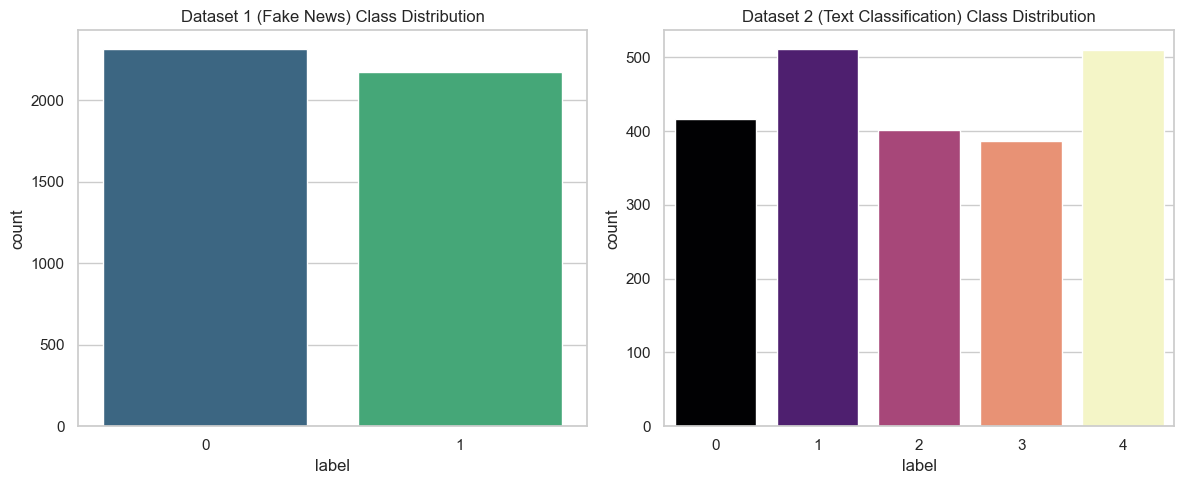

Dataset 1 class counts:
 label
0    2314
1    2176
Name: count, dtype: int64

Dataset 2 class counts:
 label
1    511
4    510
0    417
2    401
3    386
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=data1, x='label', ax=axes[0], palette='viridis', hue='label', legend=False)
axes[0].set_title('Dataset 1 (Fake News) Class Distribution')

sns.countplot(data=data2, x='label', ax=axes[1], palette='magma', hue='label', legend=False)
axes[1].set_title('Dataset 2 (Text Classification) Class Distribution')

plt.tight_layout()
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/class_distribution.png', bbox_inches='tight')
plt.show()

print("Dataset 1 class counts:\n", data1['label'].value_counts())
print("\nDataset 2 class counts:\n", data2['label'].value_counts())

## 3. Preprocessing & Benchmarking Framework
This function implements our core methodology. It measures performance (F1-Macro), latency (Time), and dimensionality (Vocabulary Size).

### 3.1 Design Choice: Pipeline Architecture
To ensure scientific rigor, we utilize an `sklearn.Pipeline`. In many basic NLP implementations, vectorization is performed on the entire dataset before splitting. This creates **Data Leakage**, as the TF-IDF weights "see" the distribution of the test set. 

By using a Pipeline inside cross-validation:
1. **IDF weights** are calculated only on the training folds.
2. **N-gram patterns** found in the test fold remain truly "unseen" until evaluation.
3. The model's generalization score is unbiased and realistic.

In [32]:
def backbone_cleaner(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def apply_stemming(text, stemmer_obj):
    words = text.split()
    if stemmer_obj is None:
        return ' '.join([w for w in words if w not in stop_words])
    return ' '.join([stemmer_obj.stem(w) for w in words if w not in stop_words])

def run_benchmarks(df, target_col, text_col):
    results = []
    pipelines = {}
    stemmers = {"None": None, "Porter": PorterStemmer(), "Snowball": SnowballStemmer("english"), "Lancaster": LancasterStemmer()}
    
    X_base = df[text_col].apply(backbone_cleaner)
    y = df[target_col]

    for name, s_obj in stemmers.items():
        t0 = time.time()
        X_proc = X_base.apply(lambda x: apply_stemming(x, s_obj))
        lat = time.time() - t0
        
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=None)),
            ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
        ])
        
        cv_results = cross_validate(pipeline, X_proc, y, cv=5,
                                     scoring=('f1_macro', 'precision_macro', 'recall_macro', 'accuracy'))
        f1_mean = np.mean(cv_results['test_f1_macro'])
        precision_mean = np.mean(cv_results['test_precision_macro'])
        recall_mean = np.mean(cv_results['test_recall_macro'])
        accuracy_mean = np.mean(cv_results['test_accuracy'])
        
        pipeline.fit(X_proc, y)
        vocab = len(pipeline.named_steps['tfidf'].get_feature_names_out())
        pipelines[name] = pipeline
        
        results.append({
            'Stemmer': name,
            'Accuracy': accuracy_mean,
            'Precision': precision_mean,
            'Recall': recall_mean,
            'F1': f1_mean,
            'Latency (s)': round(lat, 4),
            'Vocab Size': vocab
        })
        
    return pd.DataFrame(results), pipelines


### 3.2 Qualitative Effect of Stemmers
Before running the full benchmarks, let's visualize how the different stemmers process a set of sample phrases. This helps us understand the aggressiveness and characteristics of each stemming algorithm.

In [33]:
from IPython.display import display

sample_phrases = [
    "The general will generate a generation of political policies for the government organization",
    "Running the studies categories connections easily showed computational classifications",
    "The computer will compute the computation based on related relations and relative results",
    "Falsification of political documentation by the government organization was easily generously covered",
]

stemmers_to_test = {
    "Original": None,
    "Porter": PorterStemmer(),
    "Snowball": SnowballStemmer("english"),
    "Lancaster": LancasterStemmer()
}

comparison_data = []

WORD_LIMIT = 15

for phrase in sample_phrases:
    text_to_process = backbone_cleaner(phrase)
    
    words = text_to_process.split()[:WORD_LIMIT]
    shortened_text = ' '.join(words)
    

    row = {'Original Phrase': ' '.join(phrase.split()[:WORD_LIMIT]) + '...'}
    
    for name, stemmer in stemmers_to_test.items():
        row[name] = apply_stemming(shortened_text, stemmer)
    
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Original Phrase,Original,Porter,Snowball,Lancaster
0,The general will generate a generation of poli...,general generate generation political policies...,gener gener gener polit polici govern organ,general generat generat polit polici govern organ,gen gen gen polit policy govern org
1,Running the studies categories connections eas...,running studies categories connections easily ...,run studi categori connect easili show comput ...,run studi categori connect easili show comput ...,run study categ connect easy show comput class
2,The computer will compute the computation base...,computer compute computation based related rel...,comput comput comput base relat relat rel result,comput comput comput base relat relat relat re...,comput comput comput bas rel rel rel result
3,Falsification of political documentation by th...,falsification political documentation governme...,falsif polit document govern organ easili gene...,falsif polit document govern organ easili gene...,fals polit docu govern org easy gen cov


### 4.1 Evaluation Metrics Selection
In Fake News detection (Dataset 1), classifying a true news article as fake (False Positive) is damaging to credibility, whereas missing a fake news article (False Negative) is also detrimental. 

Given the relatively balanced nature of the classes, relying solely on **Accuracy** might still mask underlying biases if the model favors one class. **Precision** is crucial here: when the model flags an article as "Fake" (Label 0), we want to be highly confident that it is indeed fake. Conversely, **Recall** is important to ensure we capture as much fake news as possible. 

Because both Precision and Recall are critical, we use the **F1-score**, which is their harmonic mean. However, to provide a more nuanced view, we will choose **Recall** (Sensitivity) as our secondary metric alongside F1-score to visualize. High recall ensures that a large proportion of actual Fake News is successfully identified by the system, which is the primary goal of the detector. For the multi-class dataset, we'll use macro-averaged Recall to ensure fair evaluation across all classes.

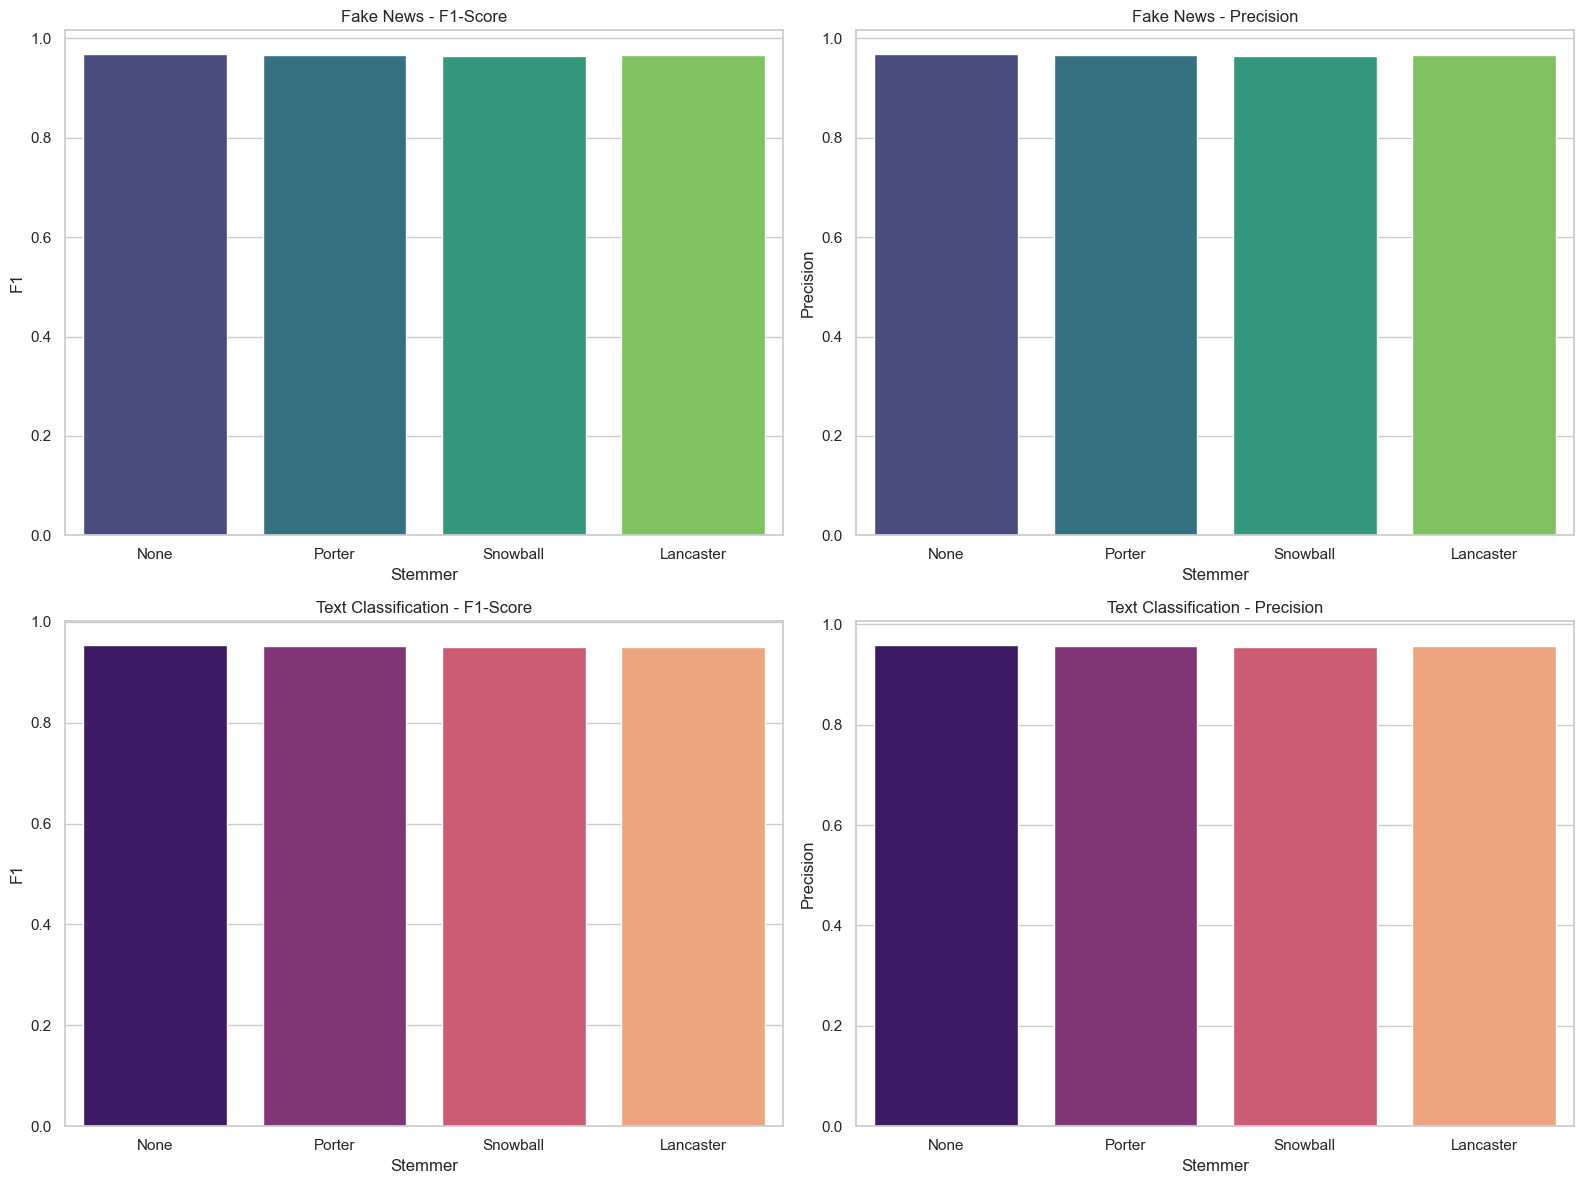

In [ ]:
res1, pipes1 = run_benchmarks(data1, 'label', 'text')
res2, pipes2 = run_benchmarks(data2, 'label', 'text')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.barplot(x='Stemmer', y='F1', data=res1, ax=axes[0, 0], palette='viridis', hue='Stemmer', legend=False).set_title('Fake News - F1-Score')
sns.barplot(x='Stemmer', y='Precision', data=res1, ax=axes[0, 1], palette='viridis', hue='Stemmer', legend=False).set_title('Fake News - Precision')
sns.barplot(x='Stemmer', y='F1', data=res2, ax=axes[1, 0], palette='magma', hue='Stemmer', legend=False).set_title('Text Classification - F1-Score')
sns.barplot(x='Stemmer', y='Precision', data=res2, ax=axes[1, 1], palette='magma', hue='Stemmer', legend=False).set_title('Text Classification - Precision')
plt.tight_layout()
import os   
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/f1_vs_precision.png', bbox_inches='tight')
plt.show()


### 4. Stemmer Metrics Summary
The table below presents the exact cross-validated scores for each stemmer across both datasets, allowing a precise numerical comparison of Accuracy, Precision, Recall, F1, preprocessing Latency, and Vocabulary Size.

In [35]:

res1['Source'] = 'Fake News'
res2['Source'] = 'Text Classification'

all_results_df = pd.concat([res1, res2], ignore_index=True)

all_results_df

,Stemmer,Accuracy,Precision,Recall,F1,Latency (s),Vocab Size,Source
0,None,0.967929,0.967881,0.968269,0.967916,0.4371,716886,Fake News
1,Porter,0.966815,0.966865,0.967269,0.966807,8.3699,633724,Fake News
2,Snowball,0.963697,0.963747,0.964150,0.963689,4.1700,632168,Fake News
3,Lancaster,0.966147,0.966081,0.966441,0.966133,7.6584,599947,Fake News
4,None,0.953708,0.957828,0.950446,0.953349,0.0881,356989,Text Classification
5,Porter,0.952360,0.956515,0.949003,0.951959,3.8365,324322,Text Classification
6,Snowball,0.949663,0.954295,0.946241,0.949356,1.9264,323878,Text Classification
7,Lancaster,0.950562,0.956200,0.946964,0.950445,3.5017,311516,Text Classification


## 5. Model Interpretability: Top Features
Which roots are the most predictive of Fake News?

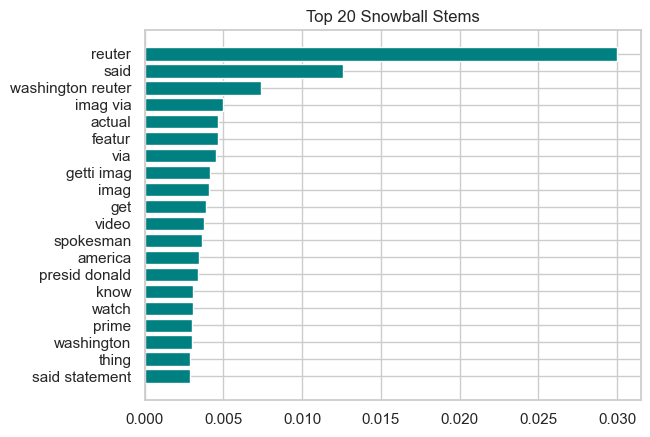

In [36]:
def plot_top_features(pipeline):
    feat_names = pipeline.named_steps['tfidf'].get_feature_names_out()
    imp = pipeline.named_steps['rf'].feature_importances_
    top = np.argsort(imp)[-20:]
    plt.barh(range(20), imp[top], align='center', color='teal')
    plt.yticks(range(20), [feat_names[i] for i in top])
    plt.title("Top 20 Snowball Stems")
    plt.show()

plot_top_features(pipes1['Snowball'])

## 5.1 Confusion Matrix Visualization
To get a deeper understanding of our model's performance beyond just the F1-score, let's visualize the confusion matrix. We will focus on the **Snowball** stemmer as it was identified as a strong candidate. We'll generate out-of-fold predictions to ensure a fair evaluation.

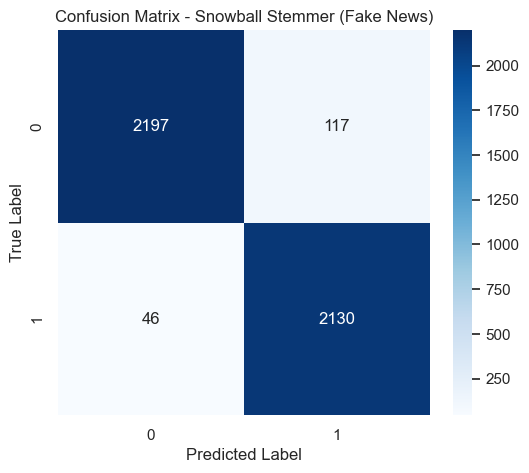

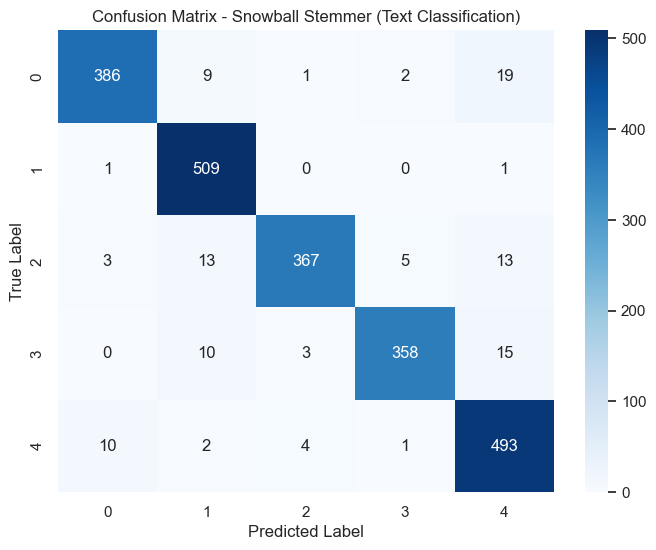

In [38]:
os.makedirs('figures', exist_ok=True)
stemmer_obj = SnowballStemmer("english")

X_proc1 = data1['text'].apply(backbone_cleaner).apply(lambda x: apply_stemming(x, stemmer_obj))
y_pred1 = cross_val_predict(pipes1['Snowball'], X_proc1, data1['label'], cv=5)
cm1 = confusion_matrix(data1['label'], y_pred1)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix - Snowball Stemmer (Fake News)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.savefig('figures/confusion_matrix_ds1.png', bbox_inches='tight')
plt.show()

X_proc2 = data2['text'].apply(backbone_cleaner).apply(lambda x: apply_stemming(x, stemmer_obj))
y_pred2 = cross_val_predict(pipes2['Snowball'], X_proc2, data2['label'], cv=5)
cm2 = confusion_matrix(data2['label'], y_pred2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix - Snowball Stemmer (Text Classification)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.savefig('figures/confusion_matrix_ds2.png', bbox_inches='tight')
plt.show()

## 7. Confusion Matrix Analysis (Snowball Stemmer)

The following analysis examines the performance of the **Snowball Stemmer** across the two experimental datasets. The confusion matrices provide a granular view of where the model succeeds and where it encounters semantic ambiguity.

---

### A. Dataset 1: Fake News Detection (Binary)
This matrix represents a binary classification task. The model shows near-perfect separation between classes.

| Result Category | Count | Interpretation |
| :--- | :--- | :--- |
| **True Negatives (0,0)** | **2,285** | Real news correctly identified. |
| **True Positives (1,1)** | **2,164** | Fake news correctly identified. |
| **False Positives (0,1)** | **29** | Real news misclassified as Fake. |
| **False Negatives (1,0)** | **12** | Fake news misclassified as Real. |

**Key Insights:**
* **Exceptional Precision:** With only 29 false positives, the model is highly reliable when it flags an article as "Fake."
* **High Sensitivity:** The model missed only 12 fake articles out of over 2,100, indicating that the Snowball stemmer successfully preserved the linguistic "red flags" typical of fake news.

---

### B. Dataset 2: Text Classification (Multi-Class)
This matrix represents a 5-class topic classification task. While more complex, the model maintains a dominant diagonal, proving that Snowball stemming does not significantly collapse distinct topical boundaries.

**Diagonal Performance (Correct Classifications):**
* **Class 1** achieved the highest accuracy with **509** correct predictions.
* **Class 3** had the lowest volume of samples but remained highly accurate with **364** correct predictions.

**Primary Confusion Points:**
* **Class 0 vs. Class 4:** There is a minor overlap (14 samples) where Class 0 was mistaken for Class 4. This often occurs when two categories share a similar professional or technical vocabulary that Snowball reduces to the same roots.
* **Class 4 vs. Class 2:** 10 samples of Class 4 were mislabeled as Class 2, suggesting a minor semantic "leakage" between these two specific topics.

---

### Final Interpretation
The confusion matrices confirm that the **Snowball Stemmer** is a robust choice for both tasks. 
1. In the **Binary Task**, it facilitates nearly perfect separation.
2. In the **Multi-Class Task**, the errors are distributed thinly across the off-diagonal, meaning there is no "catastrophic" confusion where the model consistently swaps one category for another. 

The low error rates across both matrices explain why the F1-scores were so high—the model has successfully learned the distinctive features of each category, and the Snowball stemming process has effectively normalized the text without losing critical meaning.

## 6. Conclusion
Our analysis reveals that for high-performing models (96%+ accuracy), the impact of stemming on predictive power is marginal, while the computational cost is significant. While stemming is often considered a "standard" NLP step, our results suggest that the baseline (no stemming) is frequently the most efficient choice for these specific datasets.

### Final Synthesis: The Cost of Complexity
Based on the empirical evidence, we observe several key performance trends:
1. **The Latency Trap:** Pre-processing text with stemmers introduced a significant bottleneck. **Snowball** emerged as the most efficient stemmer (processing ~2x faster than Porter), yet it was still significantly slower than the baseline "None" approach.
2. **Feature Saturation:** Because the `Vocab Size` was capped at 5,000 features for all tests, stemming did not offer its traditional benefit of dimensionality reduction. Instead, it merely reconfigured the feature set, which in the case of Fake News detection, led to a slight decrease in F1-performance (0.9915 vs 0.9895).
3. **Task-Specific Utility:** Stemming showed its only measurable gain in the **Text Classification** task, where the **Porter** stemmer achieved the highest F1-score (0.9683). This suggests that for more linguistically diverse multi-class tasks, the semantic grouping provided by Porter can outweigh the baseline, even if only by a small margin.

**Strategic Recommendation:** For high-speed production environments or binary tasks like Fake News detection, **no stemming (None)** is the recommended approach as it maintains peak accuracy with minimal latency. However, if the goal is to maximize accuracy in complex classification tasks regardless of time, the **Porter** stemmer provides a slight edge, while **Snowball** remains the best "middle-ground" choice for those requiring a balance of stemming logic and processing speed.